In [1]:
library(ggplot2)
library(GGally)
library(skimr)
library(dplyr)
library(randomForest)
set.seed(2) 

Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'GGally' a été compilé avec la version R 4.2.3"
Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2

Warning message:
"le package 'skimr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"

Attachement du package : 'dplyr'


Les objets suivants sont masqués depuis 'package:stats':

    filter, lag


Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union


randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : 'randomForest'


L'objet suivant est masqué depuis 'package:dplyr':

    combine


L'objet suivant est masqué depuis 'package:ggplot2':

    margin




In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

## Data exploration

Let us start by importing our training csv data into R.
We also set a seed so that the results are repeatable.

In [3]:
data<-read.csv("train_values.csv",stringsAsFactors = T)
data_labels<-read.csv("train_labels.csv",stringsAsFactors = T)

In [4]:
dim(data)
dim(data_labels)

[1] 260601     39

[1] 260601      2

In [5]:
head(data,3)
head(data_labels,3)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,802906,6,487,12198,2,30,6,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0
2,28830,8,900,2812,2,10,8,7,o,r,⋯,0,0,0,0,0,0,0,0,0,0
3,94947,21,363,8973,2,10,5,5,t,r,⋯,0,0,0,0,0,0,0,0,0,0


,building_id,damage_grade
,<int>,<int>
1,802906,3
2,28830,2
3,94947,3


We merge the training features and targets into the same structure

In [4]:
datam<-merge(data,data_labels,by=c('building_id','building_id'))
head(datam,3)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,4,30,266,1224,1,25,5,2,t,r,⋯,0,0,0,0,0,0,0,0,0,2
2,8,17,409,12182,2,0,13,7,t,r,⋯,0,0,0,0,0,0,0,0,0,3
3,12,17,716,7056,2,5,12,6,o,r,⋯,0,0,0,0,0,0,0,0,0,3


Let's check if there are any NA's or empty values.

In [7]:
any(is.na(datam))
any(datam[,]==" ")
any(datam[,]=="")

[1] FALSE

[1] FALSE

[1] FALSE

We check if there is any duplicate ID

In [5]:
any(duplicated(datam[,1]))

[1] FALSE

We check if there are any incoherence in the zones.

In [19]:
library(tidyr)

Warning message:
"le package 'tidyr' a été compilé avec la version R 4.2.3"


In [24]:
mean_level_1 <- datam[,2:4] %>% group_by(geo_level_3_id) %>% 
summarize(across(everything(),list(n_distinct)),)
filter(mean_level_1,geo_level_1_id_1 > 1)
filter(mean_level_1,geo_level_2_id_1 > 1)
head(mean_level_1)

geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>


geo_level_3_id,geo_level_1_id_1,geo_level_2_id_1
<int>,<int>,<int>
0,1,1
1,1,1
3,1,1
5,1,1
6,1,1
7,1,1


In [8]:
summary(datam)

  building_id      geo_level_1_id geo_level_2_id   geo_level_3_id 
 Min.   :      4   Min.   : 0.0   Min.   :   0.0   Min.   :    0  
 1st Qu.: 261190   1st Qu.: 7.0   1st Qu.: 350.0   1st Qu.: 3073  
 Median : 525757   Median :12.0   Median : 702.0   Median : 6270  
 Mean   : 525676   Mean   :13.9   Mean   : 701.1   Mean   : 6258  
 3rd Qu.: 789762   3rd Qu.:21.0   3rd Qu.:1050.0   3rd Qu.: 9412  
 Max.   :1052934   Max.   :30.0   Max.   :1427.0   Max.   :12567  
                                                                  
 count_floors_pre_eq      age         area_percentage   height_percentage
 Min.   :1.00        Min.   :  0.00   Min.   :  1.000   Min.   : 2.000   
 1st Qu.:2.00        1st Qu.: 10.00   1st Qu.:  5.000   1st Qu.: 4.000   
 Median :2.00        Median : 15.00   Median :  7.000   Median : 5.000   
 Mean   :2.13        Mean   : 26.54   Mean   :  8.018   Mean   : 5.434   
 3rd Qu.:2.00        3rd Qu.: 30.00   3rd Qu.:  9.000   3rd Qu.: 6.000   
 Max.   :9.00       

**I should select some features where looking at the histogram could bring some insights to restrict the scope.**

In [9]:
datam_stats<-skimr::skim(datam)
datam_stats

── Data Summary ────────────────────────
                           Values
Name                       datam 
Number of rows             260601
Number of columns          40    
_______________________          
Column type frequency:           
  factor                   8     
  numeric                  32    
________________________         
Group variables            None  

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable          n_missing complete_rate ordered n_unique
1 land_surface_condition         0             1 FALSE          3
2 foundation_type                0             1 FALSE          5
3 roof_type                      0             1 FALSE          3
4 ground_floor_type              0             1 FALSE          5
5 other_floor_type               0             1 FALSE          4
6 position                       0             1 FALSE          4
7 plan_configuration             0             1 FALSE         10
8 legal_o

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 15 > 1’ dans la conversion automatique vers ‘logical(1)’"


,skim_type,skim_variable,n_missing,complete_rate,factor.ordered,factor.n_unique,factor.top_counts,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,factor,land_surface_condition,0,1,FALSE,3,"t: 216757, n: 35528, o: 8316",NA,NA,NA,NA,NA,NA,NA,NA
2,factor,foundation_type,0,1,FALSE,5,"r: 219196, w: 15118, u: 14260, i: 10579",NA,NA,NA,NA,NA,NA,NA,NA
3,factor,roof_type,0,1,FALSE,3,"n: 182842, q: 61576, x: 16183",NA,NA,NA,NA,NA,NA,NA,NA
4,factor,ground_floor_type,0,1,FALSE,5,"f: 209619, x: 24877, v: 24593, z: 1004",NA,NA,NA,NA,NA,NA,NA,NA
5,factor,other_floor_type,0,1,FALSE,4,"q: 165282, x: 43448, j: 39843, s: 12028",NA,NA,NA,NA,NA,NA,NA,NA
6,factor,position,0,1,FALSE,4,"s: 202090, t: 42896, j: 13282, o: 2333",NA,NA,NA,NA,NA,NA,NA,NA
7,factor,plan_configuration,0,1,FALSE,10,"d: 250072, q: 5692, u: 3649, s: 346",NA,NA,NA,NA,NA,NA,NA,NA
8,factor,legal_ownership_status,0,1,FALSE,4,"v: 250939, a: 5512, w: 2677, r: 1473",NA,NA,NA,NA,NA,NA,NA,NA
9,numeric,building_id,0,1,NA,NA,NA,5.256755e+05,3.045450e+05,4,261190,525757,789762,1052934,▇▇▇▇▇


In [10]:
datam_stats %>% dplyr::select(skim_type, skim_variable, n_missing)

── Data Summary ────────────────────────
                           Values
Name                       datam 
Number of rows             260601
Number of columns          40    
_______________________          
Column type frequency:           
  factor                   8     
  numeric                  32    
________________________         
Group variables            None  

── Variable type: factor ───────────────────────────────────────────────────────
  skim_variable          n_missing
1 land_surface_condition         0
2 foundation_type                0
3 roof_type                      0
4 ground_floor_type              0
5 other_floor_type               0
6 position                       0
7 plan_configuration             0
8 legal_ownership_status         0

── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable                          n_missing
 1 building_id                                    0
 2 geo_level_1_id                   

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 3 > 1’ dans la conversion automatique vers ‘logical(1)’"


skim_type,skim_variable,n_missing
<chr>,<chr>,<int>
factor,land_surface_condition,0
factor,foundation_type,0
factor,roof_type,0
factor,ground_floor_type,0
factor,other_floor_type,0
factor,position,0
factor,plan_configuration,0
factor,legal_ownership_status,0
numeric,building_id,0


While engineering the variables (scaling to 0-1), we noticed that age was suspiciously low. Investigation shows that this is due to an outlier of age ~1000, while the rest of the data is <100.


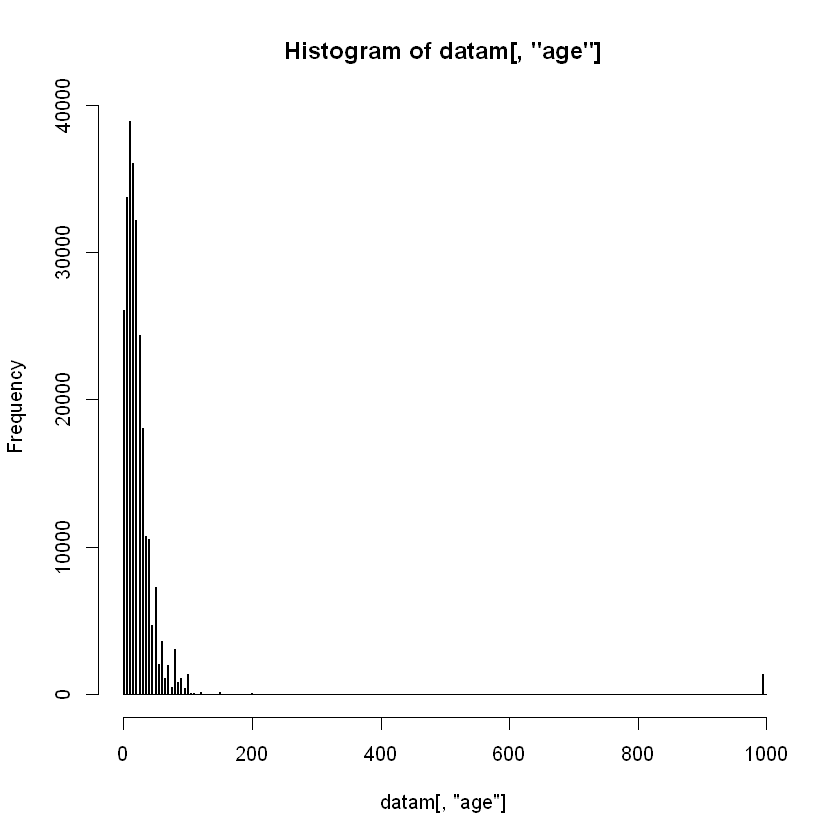

In [25]:
hist(datam[,'age'],breaks=seq(0,1000),xlim=c(0,996))

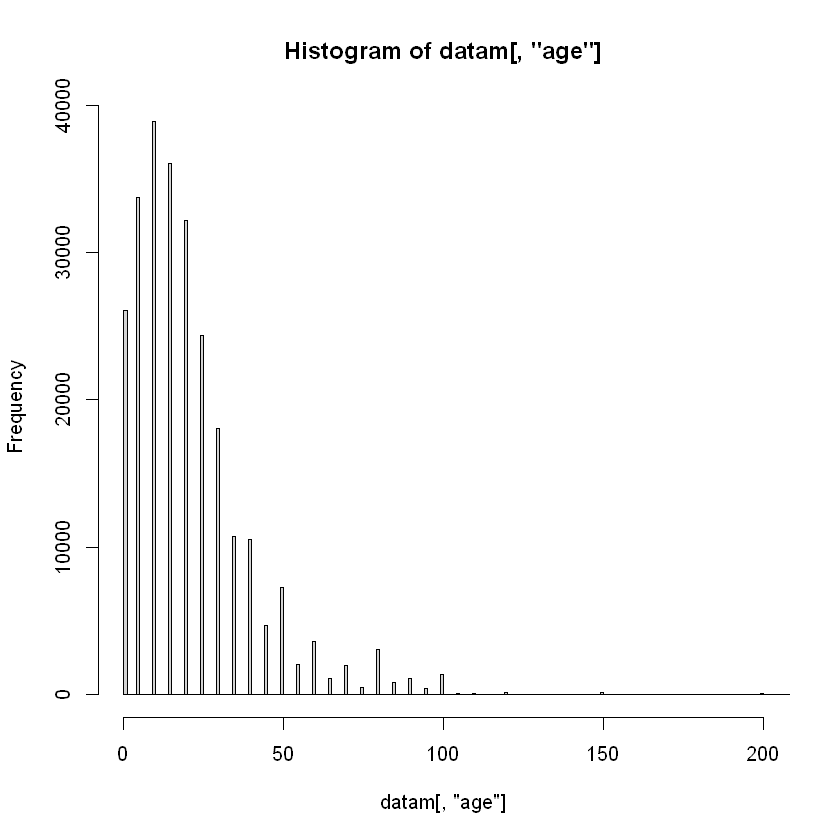

In [39]:
hist(datam[,'age'],breaks=seq(0,1000),xlim=c(0,200))

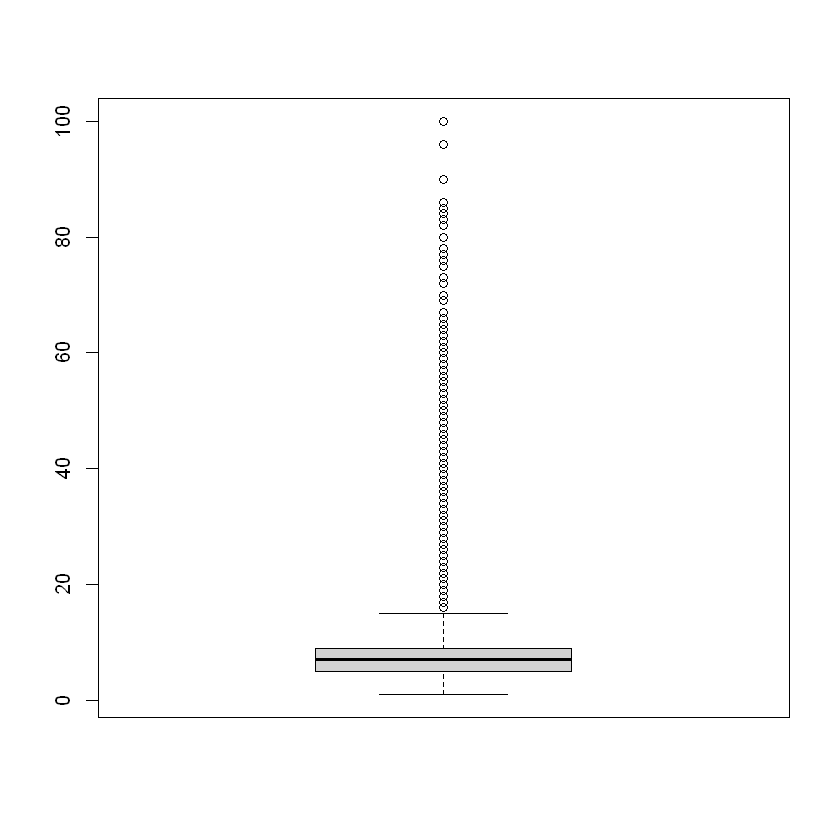

In [26]:
boxplot(datam$area_percentage)

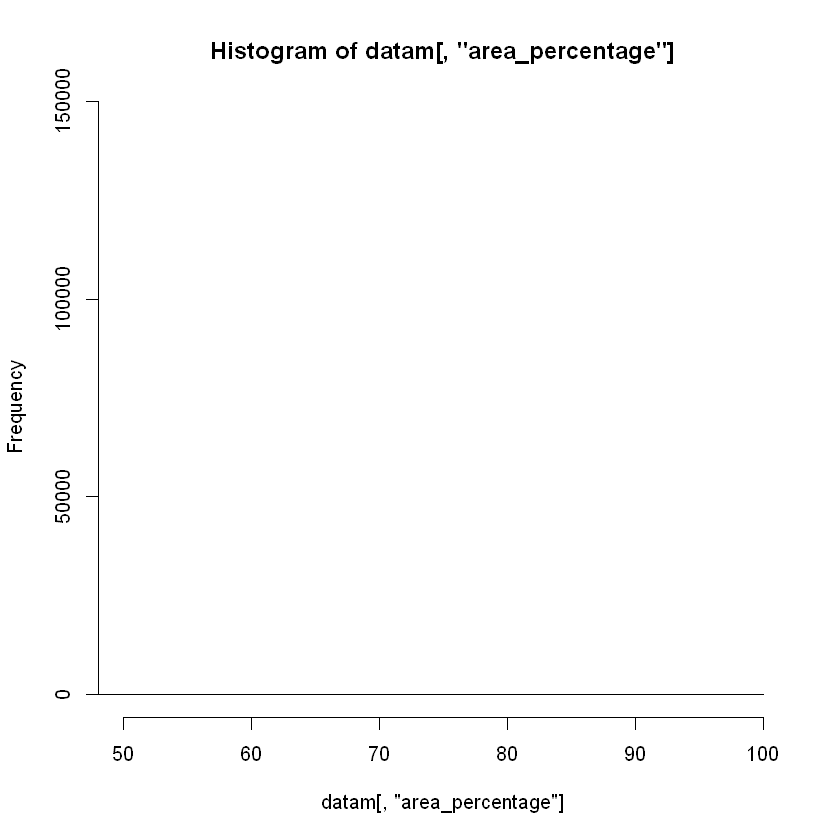

In [44]:
hist(datam[,'area_percentage'],xlim=c(50,100))

In [50]:
filter(datam[,],area_percentage > 80 & area_percentage < 100)


building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
11202,4,1342,5166,2,10,82,5,t,r,⋯,0,0,0,0,0,0,0,0,0,2
208991,25,211,2707,2,20,86,4,n,r,⋯,0,0,0,0,0,0,0,0,0,2
220534,6,1082,11745,5,20,96,15,n,i,⋯,1,0,0,0,0,0,0,0,0,2
222959,26,36,5318,1,10,83,3,t,r,⋯,0,0,0,0,0,0,0,0,0,2
242951,8,41,5708,1,30,84,3,t,r,⋯,0,0,0,0,0,0,0,0,0,3
392807,26,886,9266,2,10,86,4,t,w,⋯,0,0,0,0,0,0,0,0,0,1
421198,4,55,1996,2,20,84,5,t,r,⋯,0,0,0,0,0,0,0,0,0,3
444546,20,215,5859,2,10,85,5,t,w,⋯,0,0,0,0,0,0,0,0,0,2
498271,26,39,9897,2,25,84,7,t,u,⋯,0,0,0,0,0,0,0,0,0,1


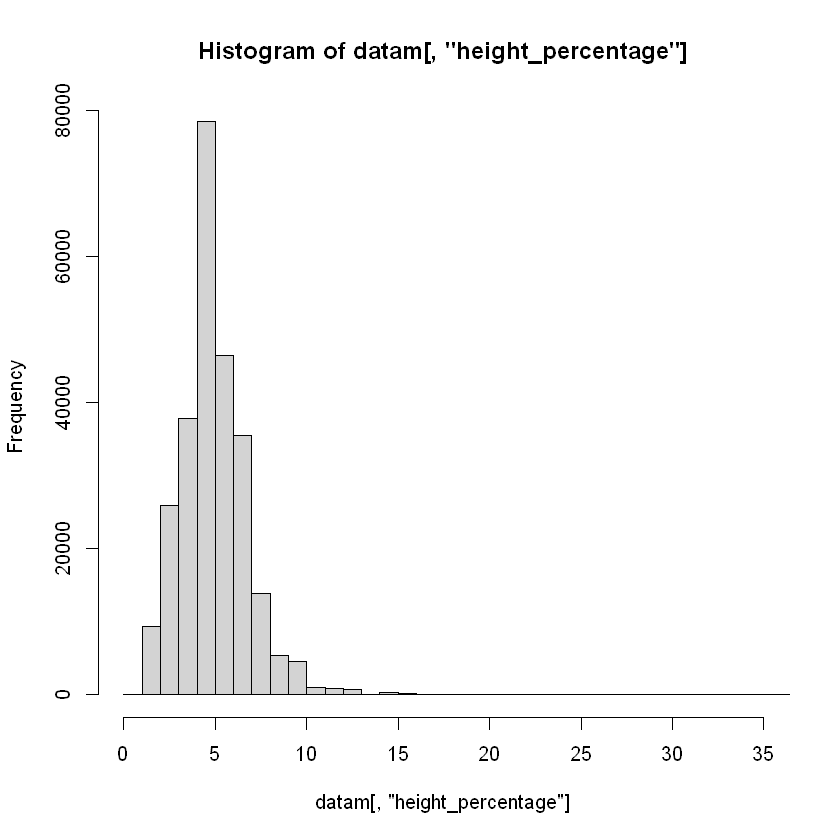

In [59]:
hist(datam[,'height_percentage'],breaks=seq(0,100),xlim=c(0,35))

In [60]:
head(filter(datam[,],height_percentage > 30 & height_percentage < 50))

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,2028,17,721,82,3,90,2,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3
2,5940,17,721,12276,3,40,3,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3
3,15950,17,721,6677,3,25,2,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3
4,31771,17,721,82,3,35,2,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3
5,40193,17,721,6677,1,10,2,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3
6,54912,17,721,82,3,25,2,32,t,r,⋯,0,0,0,0,0,0,0,0,0,3


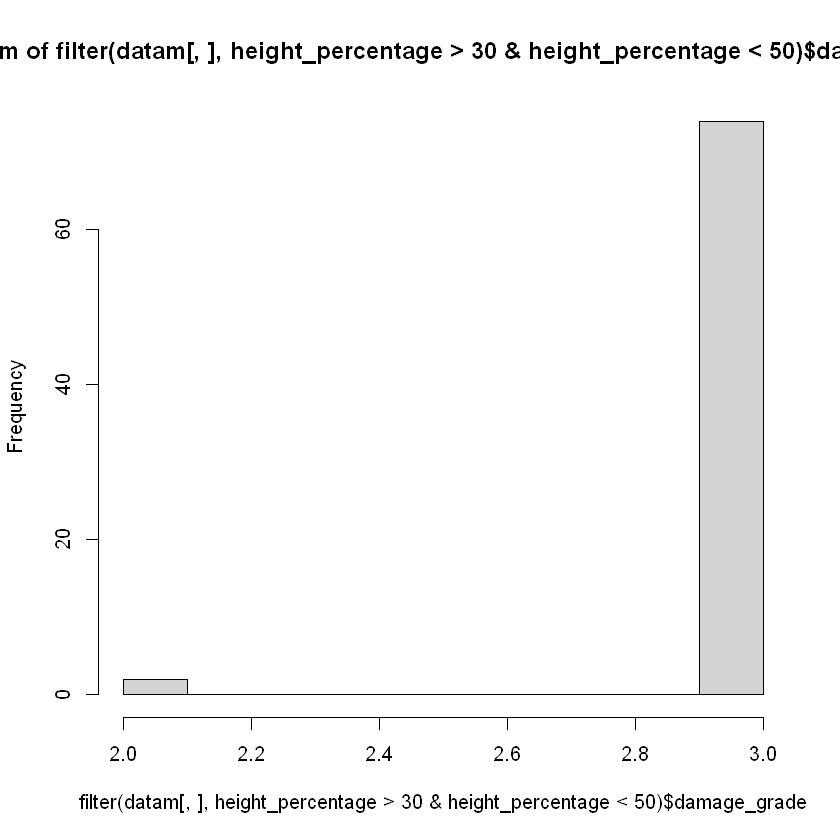

In [63]:
hist(filter(datam[,],height_percentage > 30 & height_percentage < 50)$damage_grade)

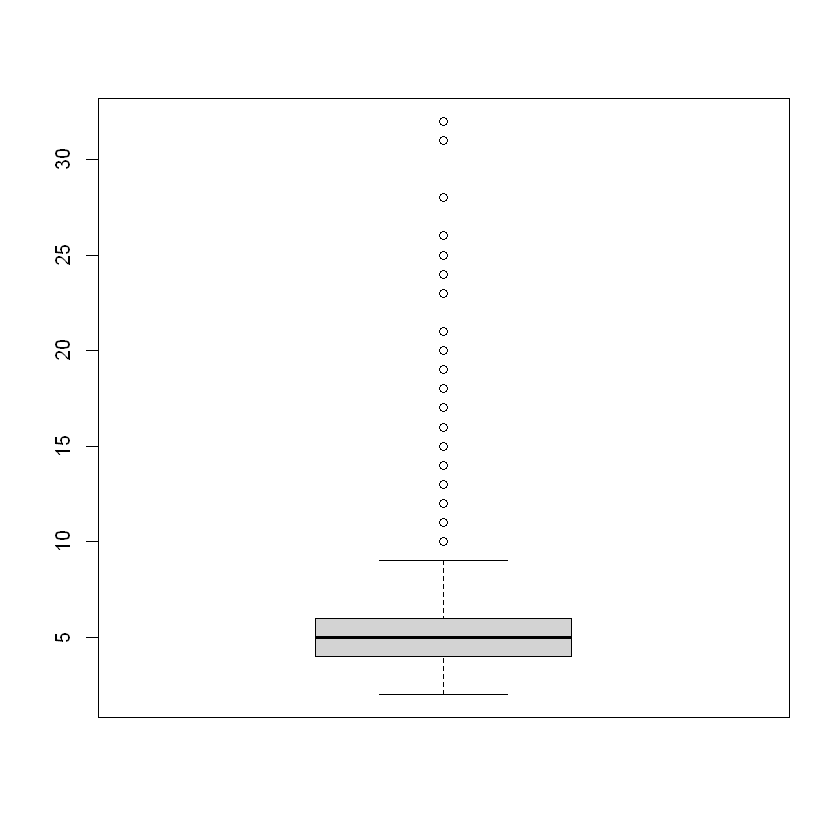

In [27]:
boxplot(datam$height_percentage)

High buildings are all at damage grade 3, so we keep it because clearly relevant

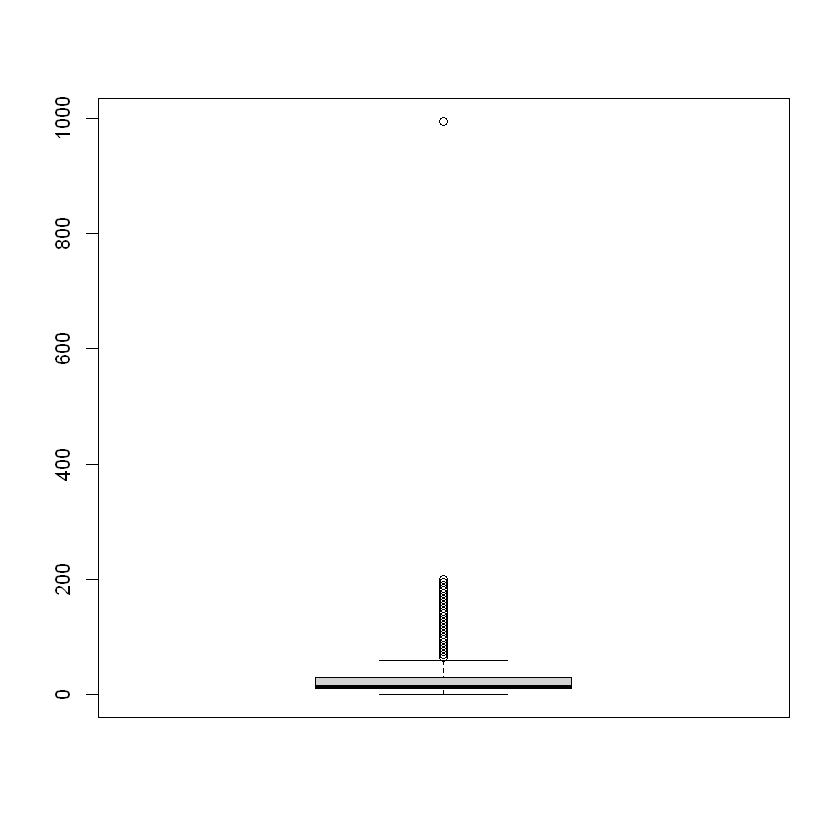

In [27]:
boxplot(datam$age)

The lines with age above 200 are extremely weird: they are all of the same peculiar age, 995. They also do not share the same geo id (even at the highest level), so it could not be a same neighbourhood built around the same time. I assume that "historical" buildings are considered automatically at 995 even if it is not their true age?

In [26]:
head(filter(datam[,],age > 200))
dim(filter(datam[,],age > 200))

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1713,2,708,2071,1,995,11,3,t,i,⋯,0,1,0,0,0,0,0,0,0,2
2,3541,8,1403,2038,2,995,6,6,n,r,⋯,0,0,0,0,0,0,0,0,0,3
3,7560,26,1132,9472,2,995,8,5,t,r,⋯,0,0,0,0,0,0,0,0,0,3
4,8321,6,314,12526,2,995,6,7,t,r,⋯,0,0,0,0,0,0,0,0,0,2
5,8408,17,957,8213,3,995,14,7,t,r,⋯,0,0,0,0,0,0,0,0,0,3
6,9269,24,628,11511,2,995,8,5,n,r,⋯,0,0,0,0,0,0,0,0,0,2


[1] 1390   40

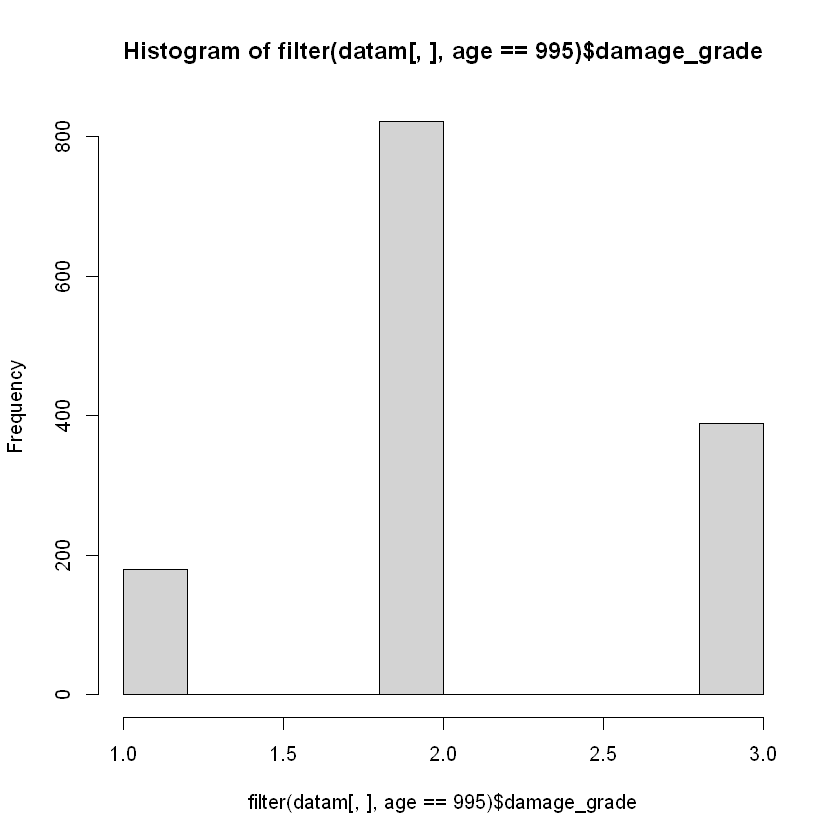

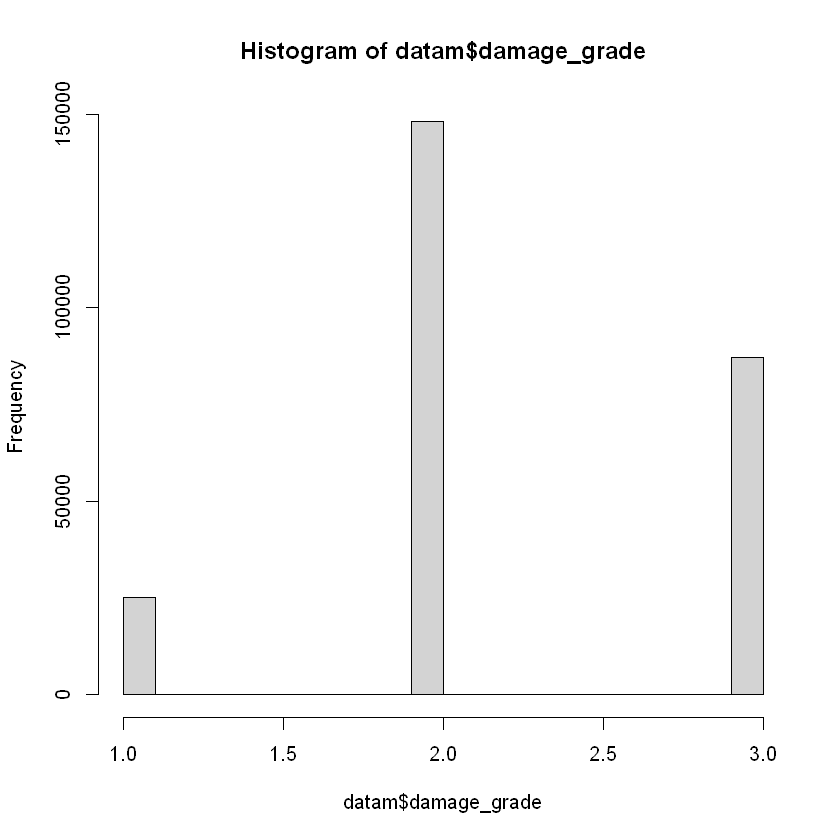

In [56]:
hist(filter(datam[,],age==995)$damage_grade)
hist(datam$damage_grade)

**This leads us to wonder if there is any other variable with outliers... Area percentage?**

### Variable engineering

Some variables are categorical. We wil now one-hot encode them.

In [11]:
factor_variables<-which(sapply(datam[1,],class)=="factor")
factor_variables

land_surface_condition        foundation_type              roof_type 
                     9                     10                     11 
     ground_floor_type       other_floor_type               position 
                    12                     13                     14 
    plan_configuration legal_ownership_status 
                    15                     27

In [12]:
summary(datam[,factor_variables])

 land_surface_condition foundation_type roof_type  ground_floor_type
 n: 35528               h:  1448        n:182842   f:209619         
 o:  8316               i: 10579        q: 61576   m:   508         
 t:216757               r:219196        x: 16183   v: 24593         
                        u: 14260                   x: 24877         
                        w: 15118                   z:  1004         
                                                                    
                                                                    
 other_floor_type position   plan_configuration legal_ownership_status
 j: 39843         j: 13282   d      :250072     a:  5512              
 q:165282         o:  2333   q      :  5692     r:  1473              
 s: 12028         s:202090   u      :  3649     v:250939              
 x: 43448         t: 42896   s      :   346     w:  2677              
                             c      :   325                           
                      

In [13]:
datam_unfactor<-datam[,-factor_variables]
head(datam_unfactor,3)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,4,30,266,1224,1,25,5,2,0,1,⋯,0,0,0,0,0,0,0,0,0,2
2,8,17,409,12182,2,0,13,7,0,1,⋯,0,0,0,0,0,0,0,0,0,3
3,12,17,716,7056,2,5,12,6,0,1,⋯,0,0,0,0,0,0,0,0,0,3


In [14]:
library('dummies')
data_onehot <- dummy.data.frame(datam[,factor_variables], sep="_")

dummies-1.5.6 provided by Decision Patterns


Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == 

In [15]:
head(data_onehot,3)
head(datam_unfactor,3)

,land_surface_condition_n,land_surface_condition_o,land_surface_condition_t,foundation_type_h,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_q,⋯,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,0,0,0,0,1,0
2,0,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,1,0,0,0,1,⋯,0,0,0,0,0,0,0,0,1,0


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,4,30,266,1224,1,25,5,2,0,1,⋯,0,0,0,0,0,0,0,0,0,2
2,8,17,409,12182,2,0,13,7,0,1,⋯,0,0,0,0,0,0,0,0,0,3
3,12,17,716,7056,2,5,12,6,0,1,⋯,0,0,0,0,0,0,0,0,0,3


In [16]:
datam<-cbind(data_onehot,datam_unfactor)
head(datam,3)

,land_surface_condition_n,land_surface_condition_o,land_surface_condition_t,foundation_type_h,foundation_type_i,foundation_type_r,foundation_type_u,foundation_type_w,roof_type_n,roof_type_q,⋯,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,0,0,0,0,0,2
2,0,0,1,0,0,1,0,0,1,0,⋯,0,0,0,0,0,0,0,0,0,3
3,0,1,0,0,0,1,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,3


Some features are also categorical, but hold the type integer (geo_level_n_id and damage_grade). We will also one-hot encode them.

In [17]:
#colnames(datam)
#colnames(datam) %in% c('geo_level_1_id','geo_level_2_id','geo_level_3_id','damage_grade')
#num_cat_variables<-which(colnames(datam) %in% c('geo_level_1_id','geo_level_2_id','geo_level_3_id','damage_grade'))
#num_cat_variables

**Is there any more engineering to do? Are there interesting feature to be computed from existing ones?**

How many features do we have now?

In [18]:
datam_stats<-skimr::skim(datam)
datam_stats

── Data Summary ────────────────────────
                           Values
Name                       datam 
Number of rows             260601
Number of columns          70    
_______________________          
Column type frequency:           
  numeric                  70    
________________________         
Group variables            None  

── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable                          n_missing complete_rate    mean
 1 land_surface_condition_n                       0             1 1.36e-1
 2 land_surface_condition_o                       0             1 3.19e-2
 3 land_surface_condition_t                       0             1 8.32e-1
 4 foundation_type_h                              0             1 5.56e-3
 5 foundation_type_i                              0             1 4.06e-2
 6 foundation_type_r                              0             1 8.41e-1
 7 foundation_type_u                              0  

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 12 > 1’ dans la conversion automatique vers ‘logical(1)’"


,skim_type,skim_variable,n_missing,complete_rate,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,numeric,land_surface_condition_n,0,1,1.363310e-01,0.343140386,0,0,0,0,1,▇▁▁▁▁
2,numeric,land_surface_condition_o,0,1,3.191085e-02,0.175763103,0,0,0,0,1,▇▁▁▁▁
3,numeric,land_surface_condition_t,0,1,8.317581e-01,0.374081651,0,1,1,1,1,▂▁▁▁▇
4,numeric,foundation_type_h,0,1,5.556387e-03,0.074333941,0,0,0,0,1,▇▁▁▁▁
5,numeric,foundation_type_i,0,1,4.059463e-02,0.197349566,0,0,0,0,1,▇▁▁▁▁
6,numeric,foundation_type_r,0,1,8.411173e-01,0.365567402,0,1,1,1,1,▂▁▁▁▇
7,numeric,foundation_type_u,0,1,5.471967e-02,0.227432680,0,0,0,0,1,▇▁▁▁▁
8,numeric,foundation_type_w,0,1,5.801206e-02,0.233766695,0,0,0,0,1,▇▁▁▁▁
9,numeric,roof_type_n,0,1,7.016166e-01,0.457549484,0,0,1,1,1,▃▁▁▁▇


### Normalization

Should we normalize the dataset? We lose some interpretation of the final results, but some features have quite different ranges, so it may be necessary for some methods (DNN). We will not normalize binary and categorical features.

**to do**

## Statistics on the dataset

In [19]:
datam_stats

── Data Summary ────────────────────────
                           Values
Name                       datam 
Number of rows             260601
Number of columns          70    
_______________________          
Column type frequency:           
  numeric                  70    
________________________         
Group variables            None  

── Variable type: numeric ──────────────────────────────────────────────────────
   skim_variable                          n_missing complete_rate    mean
 1 land_surface_condition_n                       0             1 1.36e-1
 2 land_surface_condition_o                       0             1 3.19e-2
 3 land_surface_condition_t                       0             1 8.32e-1
 4 foundation_type_h                              0             1 5.56e-3
 5 foundation_type_i                              0             1 4.06e-2
 6 foundation_type_r                              0             1 8.41e-1
 7 foundation_type_u                              0  

Warning message in is.null(text_repr) || nchar(text_repr) == 0L:
"‘length(x) = 12 > 1’ dans la conversion automatique vers ‘logical(1)’"


,skim_type,skim_variable,n_missing,complete_rate,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,numeric,land_surface_condition_n,0,1,1.363310e-01,0.343140386,0,0,0,0,1,▇▁▁▁▁
2,numeric,land_surface_condition_o,0,1,3.191085e-02,0.175763103,0,0,0,0,1,▇▁▁▁▁
3,numeric,land_surface_condition_t,0,1,8.317581e-01,0.374081651,0,1,1,1,1,▂▁▁▁▇
4,numeric,foundation_type_h,0,1,5.556387e-03,0.074333941,0,0,0,0,1,▇▁▁▁▁
5,numeric,foundation_type_i,0,1,4.059463e-02,0.197349566,0,0,0,0,1,▇▁▁▁▁
6,numeric,foundation_type_r,0,1,8.411173e-01,0.365567402,0,1,1,1,1,▂▁▁▁▇
7,numeric,foundation_type_u,0,1,5.471967e-02,0.227432680,0,0,0,0,1,▇▁▁▁▁
8,numeric,foundation_type_w,0,1,5.801206e-02,0.233766695,0,0,0,0,1,▇▁▁▁▁
9,numeric,roof_type_n,0,1,7.016166e-01,0.457549484,0,0,1,1,1,▃▁▁▁▇


There seem to be no variable with variance which is completely zero, the lowest being around 9e-3. 

In [20]:
data_cor=cor(datam)
dim(data_cor)

[1] 70 70

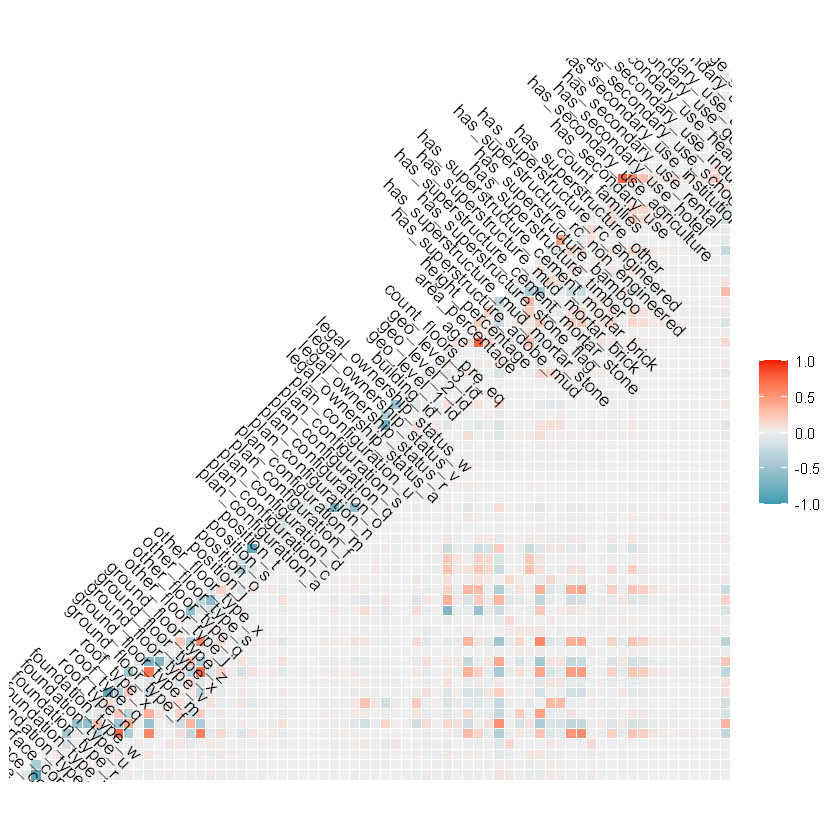

In [21]:
ggcorr(datam,cor_matrix=data_cor,angle=-45)

In [22]:
sum((abs(data_cor-diag(rep(1,nrow(data_cor)))))>0.5)/2
which(abs(data_cor-diag(rep(1,nrow(data_cor))))>0.5,arr.ind=TRUE)

[1] 28

,row,col
land_surface_condition_t,3,1
land_surface_condition_n,1,3
roof_type_x,11,5
ground_floor_type_v,14,5
other_floor_type_s,19,5
has_superstructure_rc_engineered,56,5
foundation_type_u,7,6
foundation_type_w,8,6
ground_floor_type_v,14,6
has_superstructure_mud_mortar_stone,48,6


**Should we remove already variables who are correlated with others? Use an F-test instead of this arbitrary threshold?** 

## Feature selection

In addition to removing variables which are correlated to each other, we can also identify the most relevant features and sort them in order of importance though mRMR. We can use those afterwards to evaluate how does the precisions of the model increase as we keep adding features by order of relevancy, and identify where we could stop.

In [23]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)
n<-ncol(datam)
targets=c(n)
correlation<-abs(cor(datam[,-targets,drop=F],datam[,targets,drop=F]))
selected<-c()
candidates<-1:n

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-cor(datam[,selected,drop=F],datam[,candidates,drop=F])
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    ranking <- selected

In [24]:
ranking
colnames(datam)[ranking]

[1]  6 14  8 48 11 12 52  5 18  7 17 43 19  9 10 56 55 20 53 35 37 45 47 49 61
[26] 62 23 24 40 27 34 41 58 54 50 38 59 44 15 57 32 25 26 63 21 16 13  4  2  3
[51]  1 46 31 33 69 42 36 65 64 66 67 29 51 60 30 28 68 39 22

[1] "foundation_type_r"                     
 [2] "ground_floor_type_v"                   
 [3] "foundation_type_w"                     
 [4] "has_superstructure_mud_mortar_stone"   
 [5] "roof_type_x"                           
 [6] "ground_floor_type_f"                   
 [7] "has_superstructure_cement_mortar_brick"
 [8] "foundation_type_i"                     
 [9] "other_floor_type_q"                    
[10] "foundation_type_u"                     
[11] "other_floor_type_j"                    
[12] "count_floors_pre_eq"                   
[13] "other_floor_type_s"                    
[14] "roof_type_n"                           
[15] "roof_type_q"                           
[16] "has_superstructure_rc_engineered"      
[17] "has_superstructure_rc_non_engineered"  
[18] "other_floor_type_x"                    
[19] "has_superstructure_timber"             
[20] "legal_ownership_status_a"              
[21] "legal_ownership_status_v"              
[22] "area_percentage"                       
[23] "has_superstructure_adobe_mud"          
[24] "has_superstructure_stone_flag"         
[25] "has_secondary_use_hotel"               
[26] "has_secondary_use_rental"              
[27] "position_s"                            
[28] "position_t"                            
[29] "geo_level_1_id"                        
[30] "plan_configuration_d"                  
[31] "plan_configuration_u"                  
[32] "geo_level_2_id"                        
[33] "count_families"                        
[34] "has_superstructure_bamboo"             
[35] "has_superstructure_cement_mortar_stone"
[36] "legal_ownership_status_w"              
[37] "has_secondary_use"                     
[38] "age"                                   
[39] "ground_floor_type_x"                   
[40] "has_superstructure_other"              
[41] "plan_configuration_q"                  
[42] "plan_configuration_a"                  
[43] "plan_configuration_c"                  
[44] "has_secondary_use_institution"         
[45] "position_j"                            
[46] "ground_floor_type_z"                   
[47] "ground_floor_type_m"                   
[48] "foundation_type_h"                     
[49] "land_surface_condition_o"              
[50] "land_surface_condition_t"              
[51] "land_surface_condition_n"              
[52] "height_percentage"                     
[53] "plan_configuration_o"                  
[54] "plan_configuration_s"                  
[55] "has_secondary_use_other"               
[56] "geo_level_3_id"                        
[57] "legal_ownership_status_r"              
[58] "has_secondary_use_industry"            
[59] "has_secondary_use_school"              
[60] "has_secondary_use_health_post"         
[61] "has_secondary_use_gov_office"          
[62] "plan_configuration_m"                  
[63] "has_superstructure_mud_mortar_brick"   
[64] "has_secondary_use_agriculture"         
[65] "plan_configuration_n"                  
[66] "plan_configuration_f"                  
[67] "has_secondary_use_use_police"          
[68] "building_id"                           
[69] "position_o"

## Model selection
### Random forest

In this section, I will first implement a random forest algorithm that will be benchmarked against other learning procedures.

In random forest, we have as tunables parameters : 

- The number of trees
- The threshold used to discriminate between target category
- The criteria to use to split the trees (Gini or Entropy)
- Number of features used at each split
- Tree depths

We will also need to create a test set for our algorithm. For this, we will split our database into two parts, with 0.8 as training set and 0.2 as testing set. We will scan for the amount of trees to use with a loop on the option ntree, and use the randomForest package function tuneRF to find the optimal mtry for the tree size we chose in the previous step. Finally, the function rfcv will allow us to perform multiple k-fold CV by reducing each time the amount of features used, using the importance list computed by a first run. This will allow us to see if remove those unimportant features decreases too much the quality of our fit.

We scan both on n_trees and use tuneRF to scan on mtry (with default behaviour). This shows that mtry=12 is better.

In [18]:
n_trees <- c(10,20,100,200,500)
accuracy_vec <- list()
nrows<-nrow(datam)*0.1
datam_idx <- sample(1:nrows)
split <- floor(nrows*0.8)
target_variable <- ncol(datam)-1
id_variable <- match('building_id',datam)

for (i in n_trees){ 
    #3.1 Take the first half of the dataset as a training data set
    print(paste("Number of trees used:",i))
    train_data <- datam[datam_idx[1:split],-id_variable]

    #3.2 Take the second half of the dataset as a hold out or test data set
    test_data <- datam[datam_idx[(split+1):nrows],-id_variable]
    
    #model <- randomForest(x=train_data[,-c(target_variable)],
    #                      y=as.factor(train_data[,c(target_variable)]),
    #                      ntree=i,mtry=64,doBest=TRUE,keep.forest=TRUE,importance=TRUE,do.trace=TRUE)
    model<-tuneRF(x=train_data[,-c(target_variable)],
          y=as.factor(train_data[,c(target_variable)]),ntreeTry=i,plot=TRUE,trace=TRUE,doBest=TRUE,importance=TRUE,do.trace=TRUE)
    model
    yhat<-predict(model,test_data[,-c(target_variable)])                      
    accuracy_vec<-append(accuracy_vec,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat))
    print(paste("Best F1 Score - ",i, 'trees',tail(accuracy_vec,n=1)))
    }

plot(x=n_trees,y=accuracy_vec,main = "Number of trees influence",xlab = "Nbr of trees",ylab = "F1 Score") 
accuracy_vec

: 

: 

Let's try by starting with mtry=12, see if there is something better afterwards. A previous iteration has shown that 64 was the best, let's check it.

In [17]:
n_trees <- c(10,20,100,200,500)
accuracy_vec <- list()
nrows<-nrow(datam)*0.1
datam_idx <- sample(1:nrows)
split <- floor(nrows*0.8)
target_variable <- ncol(datam)-1 #I will remove id_variable too so I need to remove 1 col
id_variable <- match('building_id', colnames(datam))

for (i in n_trees){ 
    for (j in c(12,24,48,64)){
        #3.1 Take the first half of the dataset as a training data set
        print(paste("Number of trees used:",i,'mTry:',j))
        train_data <- datam[datam_idx[1:split],-c(id_variable)]

        #3.2 Take the second half of the dataset as a hold out or test data set
        test_data <- datam[datam_idx[(split+1):nrows],-c(id_variable)]
        
        model <- randomForest(x=train_data[,-c(target_variable)],
                              y=as.factor(train_data[,c(target_variable)]),
                              ntree=i,mtry=j,doBest=TRUE,keep.forest=TRUE,importance=TRUE,do.trace=TRUE)
        #model<-tuneRF(x=train_data[,-c(target_variable),drop=F],
        #    y=as.factor(train_data[,c(target_variable)]),ntreeTry=i,mtryStart=12,plot=TRUE,trace=TRUE,doBest=TRUE,importance=TRUE,do.trace=TRUE)
        #model
        yhat<-predict(model,test_data[,-c(target_variable),drop=F])                      
        accuracy_vec<-append(accuracy_vec,F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat))
        print(paste("Best F1 Score - ",i, 'trees','- mtry',j,':',tail(accuracy_vec,n=1)))
    }
}
plot(x=n_trees,y=accuracy_vec,main = "Number of trees influence",xlab = "Nbr of trees",ylab = "F1 Score") 
accuracy_vec


[1] "Number of trees used: 10 mTry: 12"
ntree      OOB      1      2      3
    1:  42.17% 60.44% 33.42% 51.71%
    2:  41.94% 59.34% 32.29% 53.27%
    3:  41.40% 60.00% 31.81% 52.43%
    4:  40.60% 60.11% 30.51% 52.18%
    5:  40.84% 60.35% 30.33% 53.19%
    6:  39.85% 59.52% 29.34% 52.20%
    7:  39.06% 59.18% 27.87% 52.46%
    8:  38.85% 59.80% 27.44% 52.44%
    9:  38.32% 59.34% 26.90% 51.88%
   10:  37.75% 59.53% 25.85% 51.88%
[1] "Best F1 Score -  10 trees - mtry 12 : 0.66327705295472"
[1] "Number of trees used: 10 mTry: 24"
ntree      OOB      1      2      3
    1:  40.91% 61.83% 34.48% 46.13%
    2:  40.78% 60.08% 33.84% 47.21%
    3:  40.55% 57.96% 33.18% 48.21%
    4:  40.17% 57.69% 32.89% 47.63%
    5:  39.66% 56.88% 32.00% 47.84%
    6:  39.29% 56.87% 31.01% 48.43%
    7:  38.59% 57.68% 30.30% 47.33%
    8:  37.68% 57.04% 28.94% 47.06%
    9:  37.32% 56.92% 28.57% 46.66%
   10:  36.99% 57.45% 27.99% 46.50%
[1] "Best F1 Score -  10 trees - mtry 24 : 0.663085188027629"
[1] "

ERROR: Error in xy.coords(x, y, xlabel, ylabel, log): les longueurs de 'x' et 'y' diffèrent


In [22]:
accuracy_vec

[[1]]
[1] 0.6632771

[[2]]
[1] 0.6630852

[[3]]
[1] 0.6744052

[[4]]
[1] 0.6627015

[[5]]
[1] 0.6788181

[[6]]
[1] 0.6834229

[[7]]
[1] 0.6805449

[[8]]
[1] 0.6838066

[[9]]
[1] 0.6920568

[[10]]
[1] 0.6933998

[[11]]
[1] 0.6907137

[[12]]
[1] 0.6916731

[[13]]
[1] 0.6955104

[[14]]
[1] 0.696086

[[15]]
[1] 0.6922487

[[16]]
[1] 0.6955104

[[17]]
[1] 0.6951266

[[18]]
[1] 0.6958941

[[19]]
[1] 0.6937836

[[20]]
[1] 0.6955104

We assume that it generalizes to more data, and use these optimal values on the complete dataset. We perform a k-fold CV on this random forest.

In [35]:
id_variable <- match('building_id',datam)
id_variable

[1] NA

In [24]:
k = 10
n_trees <- 200
features_per_split <- 48

target_variable <- ncol(datam)-1
id_variable <- 

accuracy_vec <- array(0,k)
threshold <- 0.5

# 1. Shuffle the dataset randomly.
datam_idx <- sample(1:nrow(datam))

# 2. Split the dataset into k groups
max <- ceiling(nrow(datam)/k)
splits <- split(datam_idx, ceiling(seq_along(datam_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){

    #3.1 Take the group as a hold out or test data set
    test_data <- datam[splits[[i]],-id_variable]


    #3.2 Take the remaining groups as a training data set
    train_data <- datam[-splits[[i]],-id_variable]   

    model <- randomForest(x=train_data[,-c(target_variable)],
                        y=as.factor(train_data[,c(target_variable)]),
                        ntree=n_trees,m try=features_per_split,keep.forest=TRUE,importance=TRUE)
    yhat<-predict(model,test_data[,-c(target_variable)])                      
    accuracy_vec[i]<-F1_Score_micro(as.factor(test_data[,c(target_variable)]),yhat)
    setTxtProgressBar(pb, i)
    print(paste("F1-Score Micro -",i,"fold:",accuracy_vec[i]))
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |                                                                      |   0%

ERROR: Error in randomForest.default(x = train_data[, -c(target_variable)], y = as.factor(train_data[, : Need at least two classes to do classification.


We can have a rankings of the features by importance. We see that the geographical id is a very important feature in the splitting, even though it presented previously no correlation. This indicates that the correlation is a bad indicator of this feature, which makes sense: those values do not hold any meaning, so a high id is not gonna correlate with a high damage id. We should maybe engineer this variable for other algorithms (linear, for example).

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69

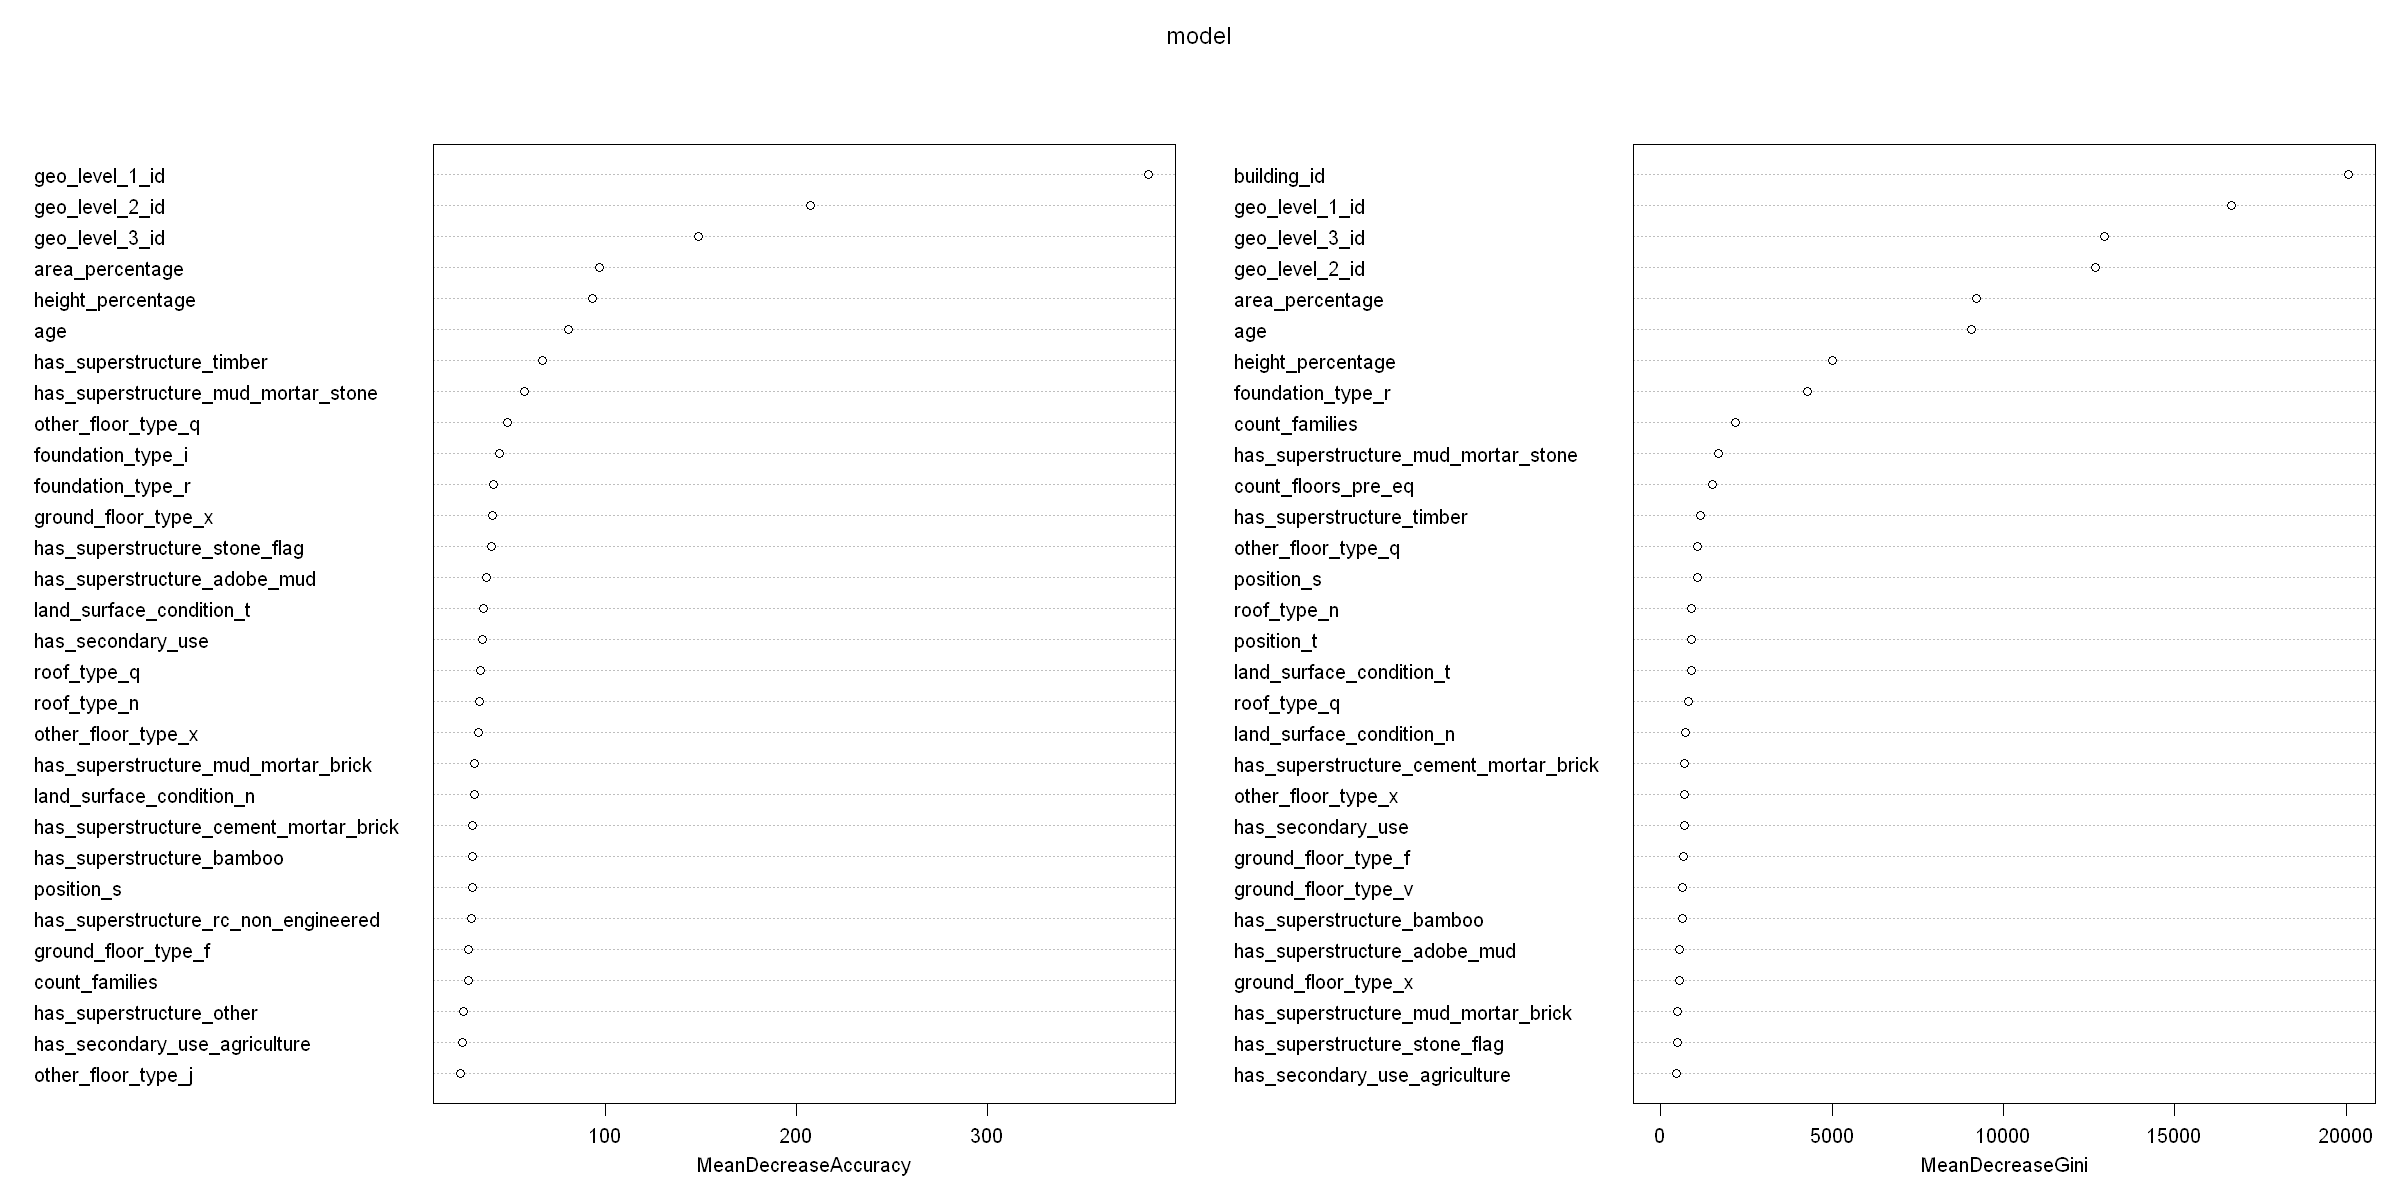

In [ ]:
options(repr.plot.width=20, repr.plot.height=10)

varImpPlot(model,scale=TRUE)

varUsed(model,count=FALSE,by.tree=FALSE) 

We can also use the function rfcv which checks the k-fold CV value of the randomforest, removing each time new features by increasing order of importance. This allows us to pinpoint which features could be neglected in this process.

In [ ]:
n_trees <- 100
features_per_split <- 64
datam_idx <- sample(1:nrow(datam))
split <- floor(nrow(datam)*0.8)
target_variable <- ncol(datam)
train_data <- datam[datam_idx[1:split],]
test_data <- datam[datam_idx[(split+1):nrow(datam)],]   

cv_RF<-rfcv(train_data[,-c(target_variable)],train_data[,c(target_variable)],cv.fold=10,ntree=n_trees,mtry=features_per_split)
with(cv_RF, plot(n.var, error.cv, log="x", type="o", lwd=2))

Let us now import the test values.

In [34]:
data_t<-read.csv("test_values.csv",stringsAsFactors = T)
factor_variables_t<-which(sapply(data_t[1,],class)=="factor")
data_unfactor_t<-data_t[,-factor_variables]
data_onehot_t <- dummy.data.frame(data_t[,factor_variables], sep="_")
data_t<-cbind(data_unfactor_t,data_onehot_t)

yhat_t<-predict(model,data_t[,-'building_id'])

yhat_t_bind<-data.frame(data_t[,'building_id'],as.numeric(yhat_t))
colnames(yhat_t_bind)<-c('building_id','damage_grade')

Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:
"‘length(x) = 2 > 1’ dans la conversion automatique vers ‘logical(1)’"
Warning message in model.matrix.default(~x - 1, model.frame(~x - 1), contrasts = FALSE):
"un argument de contrastes qui n’est pas une liste est ignoré"
Warning message in dummy.classes == "ALL" || class(data[, nm]) %in% dummy.classes:

In [71]:
write.csv(yhat_t_bind,'prediction_temp.csv',col.names=TRUE,row.names=FALSE)

Warning message in write.csv(yhat_t_bind, "prediction1.csv", col.names = TRUE, row.names = FALSE):
"une tentative de modification de 'col.names' a échoué"
